Training data shape: (404, 13)
Training targets shape: (404,)
Test data shape: (102, 13)
Test targets shape: (102,)
Epoch 1/500


c:\Users\Win 11\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 582.2413 - val_loss: 602.0516
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 564.4885 - val_loss: 584.3370
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 546.7078 - val_loss: 565.9676
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 527.0717 - val_loss: 543.1195
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 502.6429 - val_loss: 514.8461
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 472.6712 - val_loss: 480.6204
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 437.2094 - val_loss: 438.7255
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 393.3265 - val_loss: 389.1167
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 341.9356 - val_loss: 333.2215
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 287.0708 - val_loss: 272.2852
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 228.9196 - val_loss: 213.5536
Epoch 12/500
13/13 ━━━━━━━━━━━

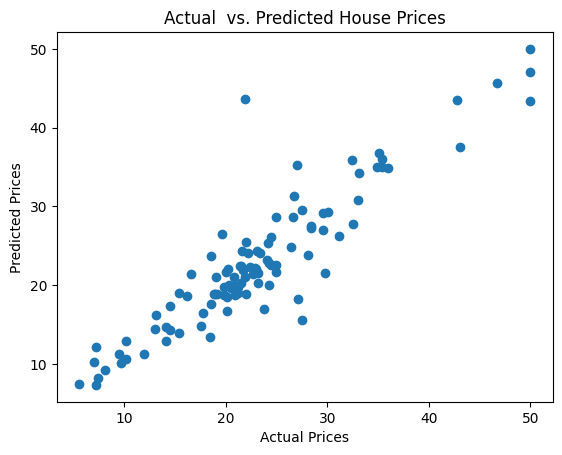

In [2]:
from sklearn.model_selection import train_test_split  
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler  
import tensorflow as tf  
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 

from keras.datasets import boston_housing

# Load the Boston Housing dataset
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

# Print the shape of the training and test datasets
print("Training data shape:", train_data.shape)
print("Training targets shape:", train_targets.shape)
print("Test data shape:", test_data.shape)
print("Test targets shape:", test_targets.shape)
# Scale the features  
scaler = StandardScaler()  
X_train_scaled = scaler.fit_transform(train_data)  
X_test_scaled = scaler.transform(test_data)  
 
# Create  the MLP model  
model = Sequential([Dense(32, activation='relu', input_dim= train_data.shape[1]), Dense(16, activation='relu'), Dense(1)])  
 
# Compile the model  
model.compile(optimizer='adam', loss='mean_squared_error')  
 
# Train the model  
model.fit(X_train_scaled,  train_targets, epochs=500, batch_size=32, 
validation_data=(X_test_scaled, test_targets))  
 
# Evaluate the model  
test_loss = model.evaluate(X_test_scaled, test_targets)  
print('Test Loss:', test_loss) 
  
# Make predictions  
y_pred = model.predict(X_test_scaled)  
 
# Visualize the predictions  
plt.scatter(test_targets, y_pred)  
plt.xlabel('Actual Prices')  
plt.ylabel('Predicted Prices')  
plt.title('Actual  vs. Predicted House Prices') 
plt.show()